## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

In [2]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [3]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GenAI/stock_news.csv")

In [5]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

In [6]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [7]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [8]:
data.shape

(349, 8)

###**Checking for missing values**

In [9]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


### **Checking for duplicate values**

In [10]:
# checking for duplicate values
data.duplicated().sum()

0

In [11]:
data[data.duplicated()]

,Date,News,Open,High,Low,Close,Volume,Label


## **Exploratory Data Analysis**

In [12]:
# To display the structure of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [13]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [14]:
# To ensure the data type of Date
data['Date'].dtype

dtype('<M8[ns]')

In [15]:
# summary statistics for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

In [16]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Label']

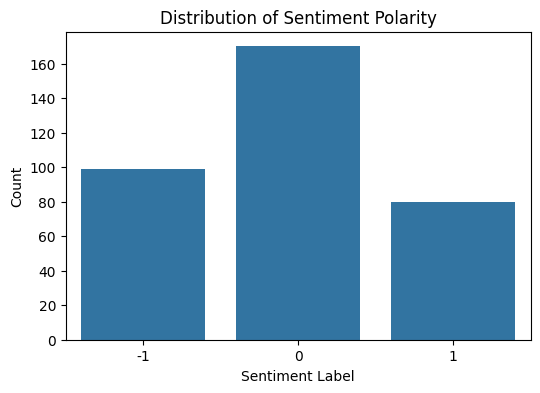

In [17]:
# Distribution of sentiment polarity
plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=data)
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

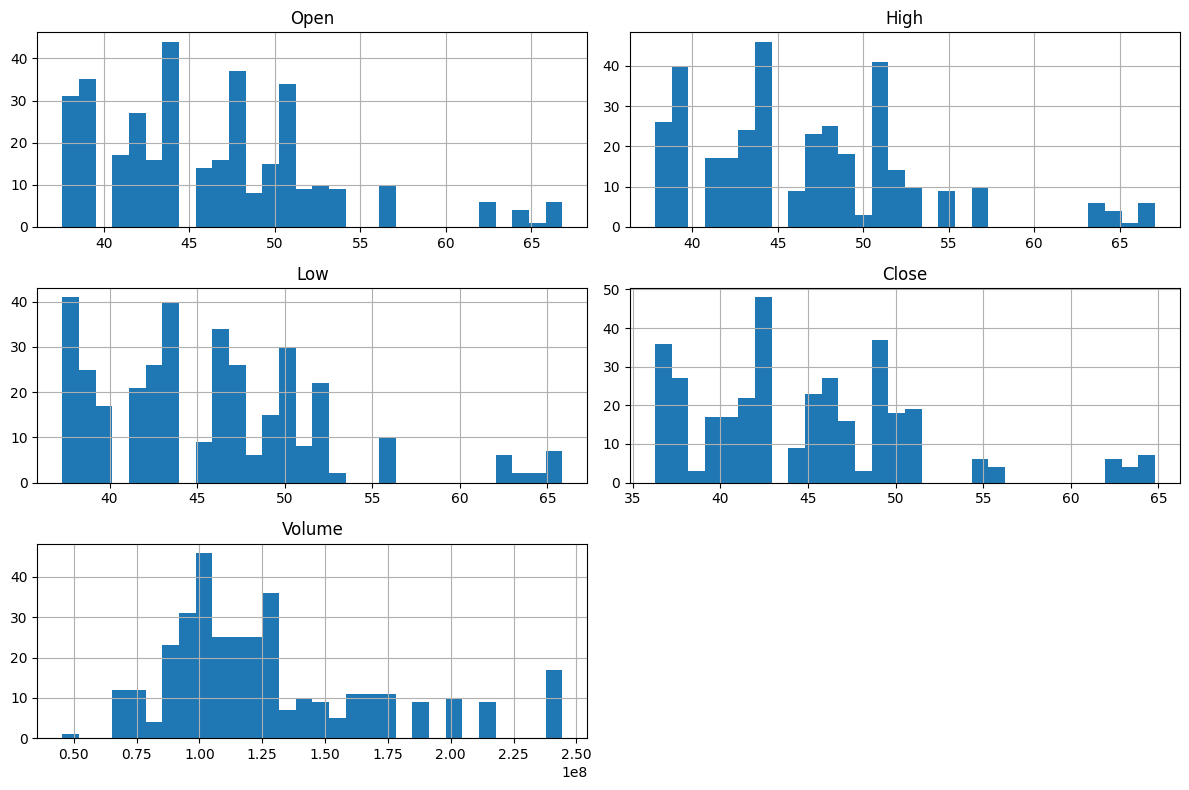

In [18]:
# Plot Distribution of all Numeric variables
data[['Open','High','Low','Close','Volume']].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()


### **Distribution of the length of news content**

In [19]:
# Compute length of news content (in words)
data['News_length'] = data['News'].apply(lambda x: len(str(x).split()))

# Summary statistics of news length
data['News_length'].describe()


,News_length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


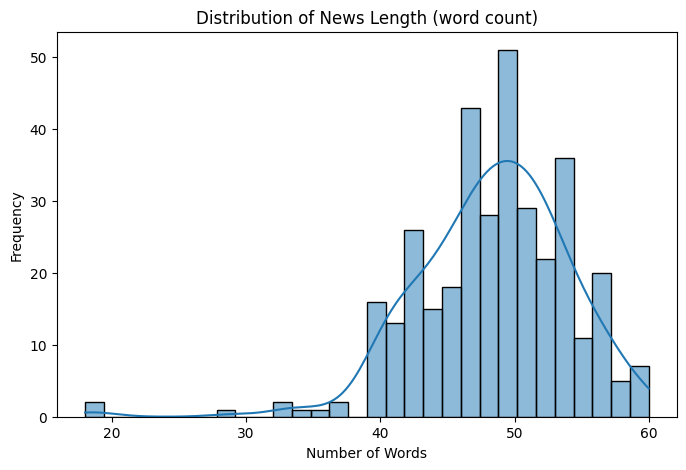

In [20]:
# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(data['News_length'], bins=30, kde=True)
plt.title('Distribution of News Length (word count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


### **Monthwise Analysis**

In [21]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


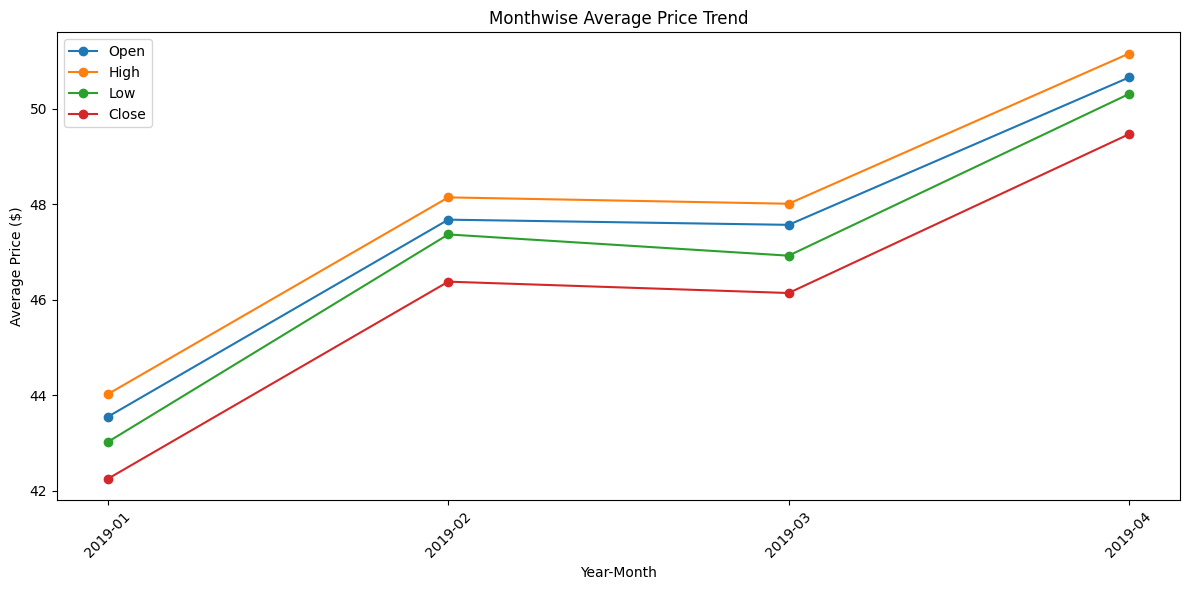

In [22]:
# plot the monthwise averages of all price variables for better visualization
plt.figure(figsize=(12,6))
for col in ['Open','High','Low','Close']:
    plt.plot(monthwise_avg['YearMonth'], monthwise_avg[col], marker='o', label=col)
plt.xticks(rotation=45)
plt.xlabel('Year-Month')
plt.ylabel('Average Price ($)')
plt.title('Monthwise Average Price Trend')
plt.legend()
plt.tight_layout()
plt.show()



* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

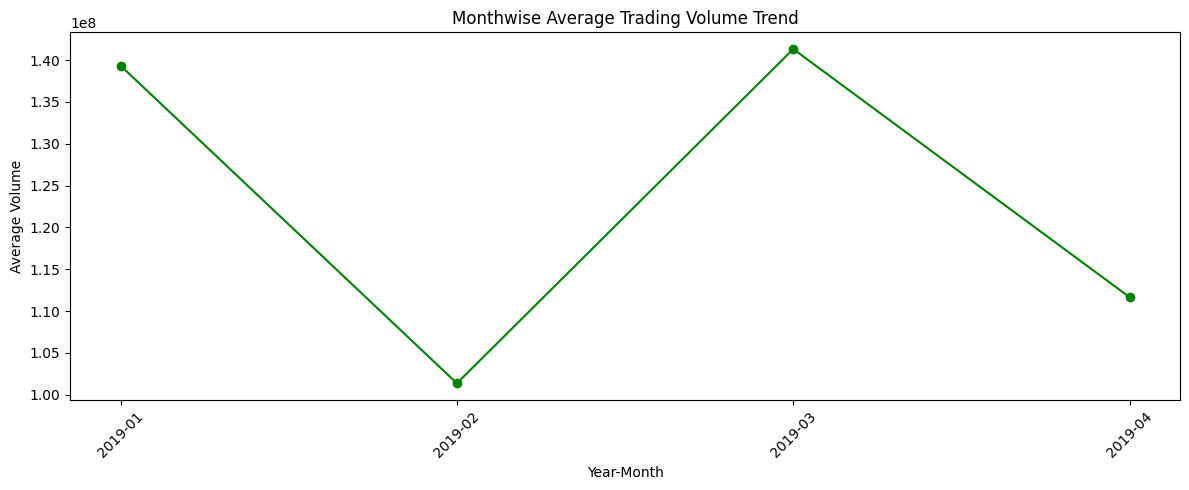

In [23]:
#plot the trend of monthwise averages in Volume
plt.figure(figsize=(12,5))
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Volume'], marker='o', color='green')
plt.xticks(rotation=45)
plt.xlabel('Year-Month')
plt.ylabel('Average Volume')
plt.title('Monthwise Average Trading Volume Trend')
plt.tight_layout()
plt.show()

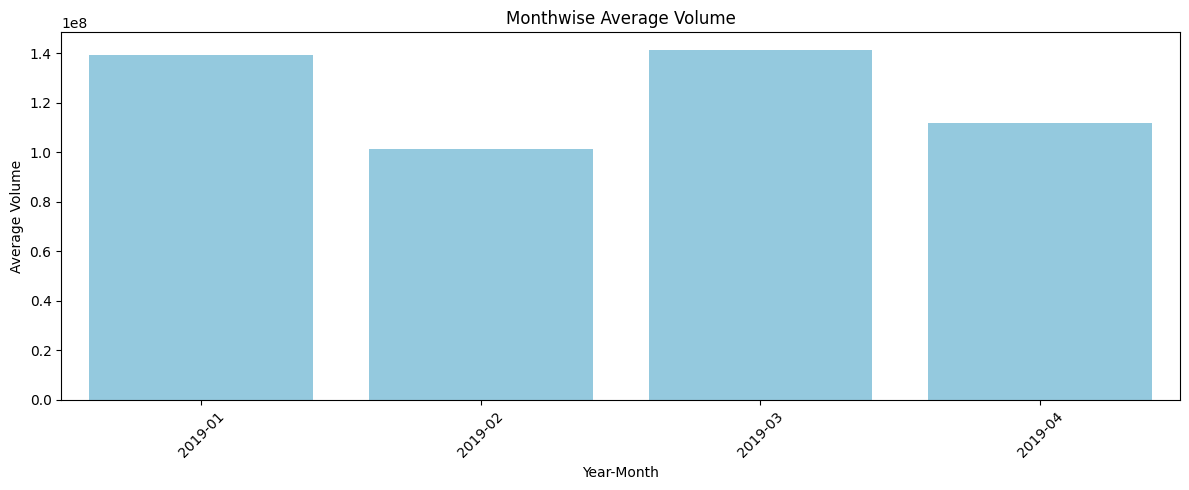

In [24]:
# Bar plot of the monthwise averages in Volume
plt.figure(figsize=(12,5))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg, color='skyblue')
plt.xticks(rotation=45)
plt.xlabel('Year-Month')
plt.ylabel('Average Volume')
plt.title('Monthwise Average Volume')
plt.tight_layout()
plt.show()

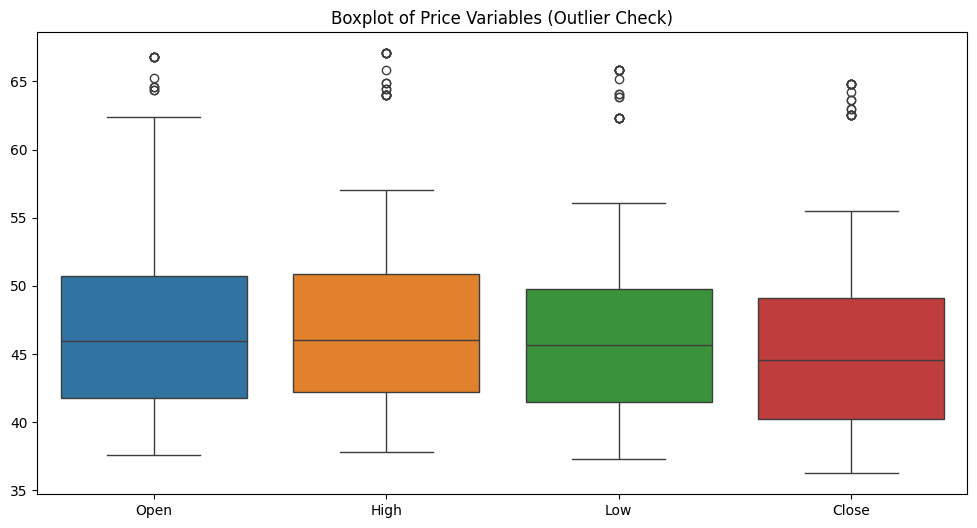

In [25]:
# Boxplot to identify outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=data[['Open','High','Low','Close']])
plt.title('Boxplot of Price Variables (Outlier Check)')
plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

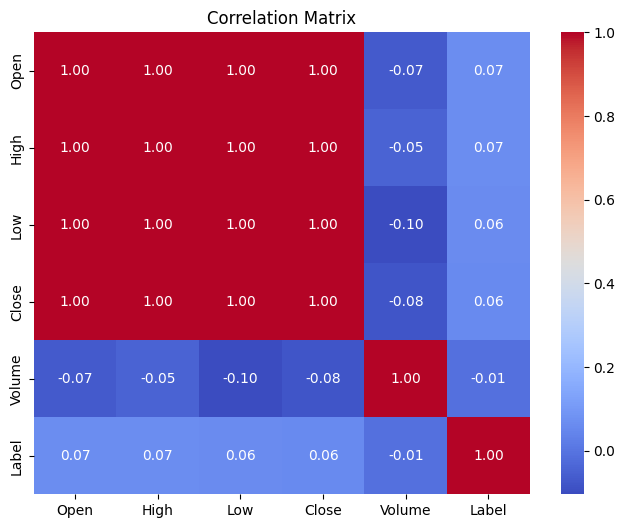

In [26]:
# Correlation matrix to check if variables move together or have correlations
plt.figure(figsize=(8,6))
corr = data[['Open','High','Low','Close','Volume','Label']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### **Sentiment Polarity vs Price**

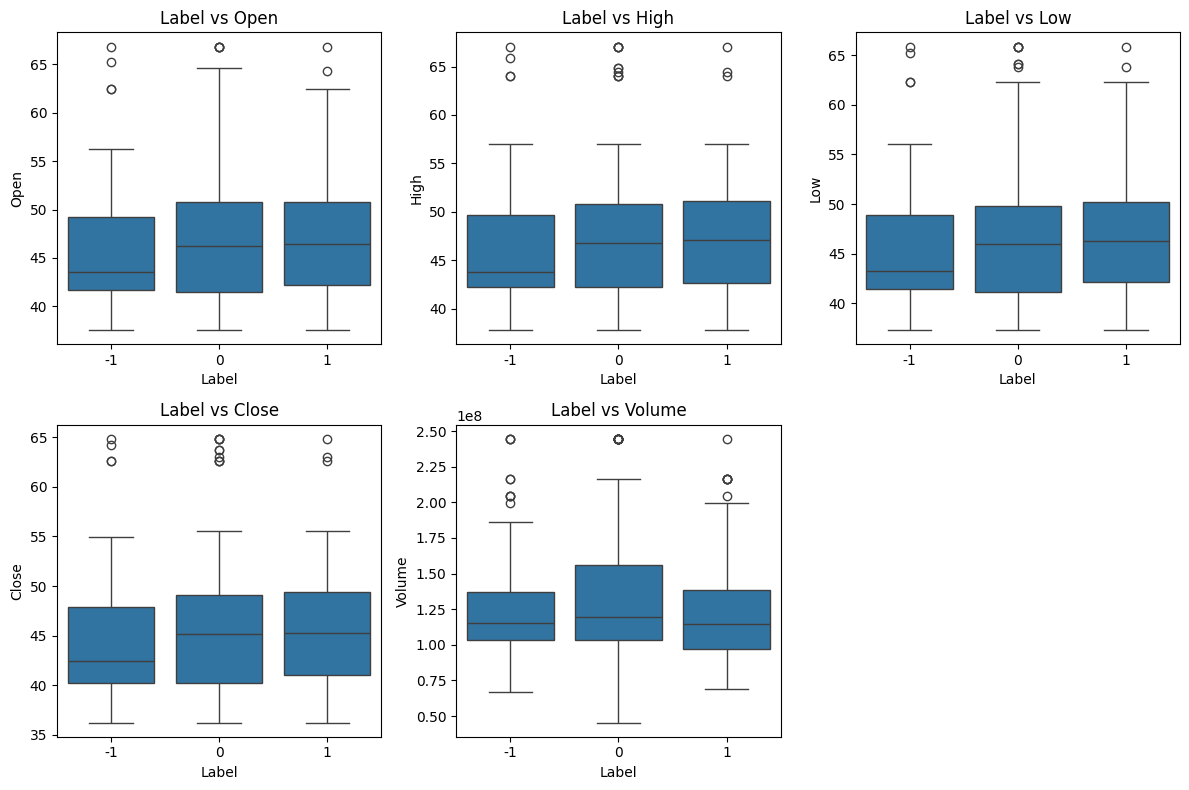

In [27]:
#Sentiment Polarity with all numeric variables
plt.figure(figsize=(12,8))
numeric_vars = ['Open','High','Low','Close','Volume']
for i, col in enumerate(numeric_vars, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x='Label', y=col, data=data)
    plt.title(f'Label vs {col}')
plt.tight_layout()
plt.show()

### **Time Series Analysis (Date vs Price)**

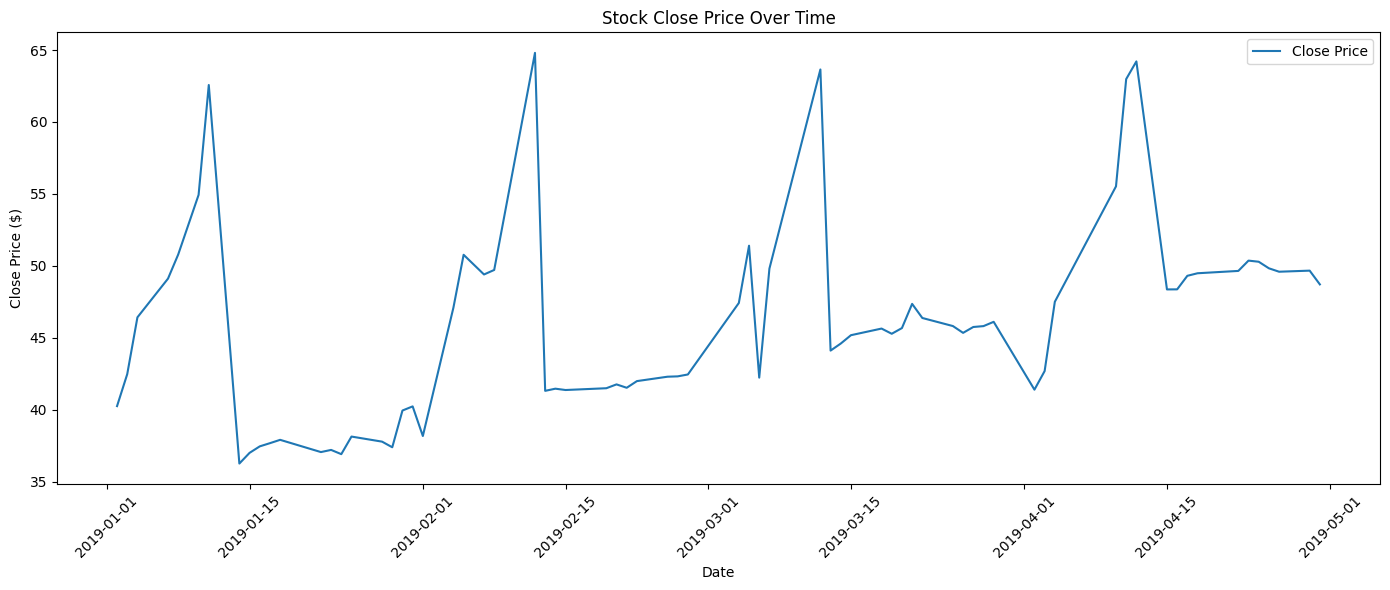

In [28]:
#Time Series Analysis (Date vs Price columns)
plt.figure(figsize=(14,6))
plt.plot(data['Date'], data['Close'], label='Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.title('Stock Close Price Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **Distribution of News Length Across Sentiment Categories**

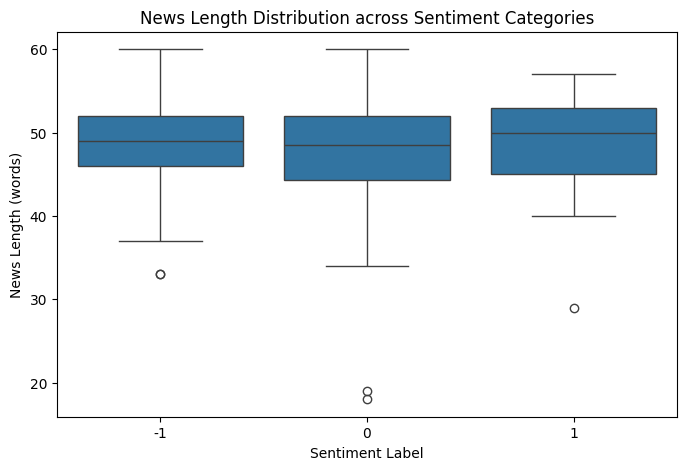

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Label', y='News_length', data=data)
plt.title('News Length Distribution across Sentiment Categories')
plt.xlabel('Sentiment Label')
plt.ylabel('News Length (words)')
plt.show()

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [30]:
# Storing target variable
y = data['Label']

## **Word Embeddings**


#### **Word2Vec**

In [31]:
# Creating a list of all words in our data
words_list = [doc.split() for doc in data['News']]

In [32]:
vec_size = 100
w2v_model = Word2Vec(sentences=words_list, vector_size=vec_size, window=5, min_count=1, workers=4, seed=42)

In [33]:
print("Vocabulary size:", len(w2v_model.wv.index_to_key))

Vocabulary size: 4681


In [34]:

# Retrieving word vectors for all the words present in the model's vocabulary
words = w2v_model.wv.index_to_key


# Creating a dictionary of words and their corresponding vectors
word_vector_dict = {word: w2v_model.wv[word] for word in words}

In [35]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [36]:
# creating a dataframe of the vectorized documents
X_word2vec = data['News'].apply(average_vectorizer_Word2Vec)
X_word2vec = pd.DataFrame(X_word2vec.tolist())
X_word2vec.shape

(349, 100)

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [37]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

##### Encoding the dataset

In [40]:
# Generating embeddings using Sentence-Transformer all-MiniLM-L6-v2
minilm_model = SentenceTransformer('all-MiniLM-L6-v2')
embedding_matrix_minilm = minilm_model.encode(data['News'].tolist(), show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [38]:
embedding_matrix = model.encode(data['News'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [41]:
# printing the shape of the embedding matrix
embedding_matrix_minilm.shape

(349, 384)

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [42]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [43]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [44]:
# Storing independent variable

X = X_word2vec


In [45]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [46]:
# Building the model
from sklearn.ensemble import RandomForestClassifier


# Fitting on train data
rf_word2vec = RandomForestClassifier(random_state=42)
rf_word2vec.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [47]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)


# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test)

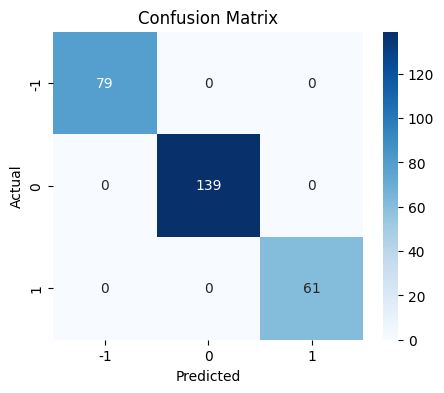

In [48]:
plot_confusion_matrix(y_train, y_pred_train)

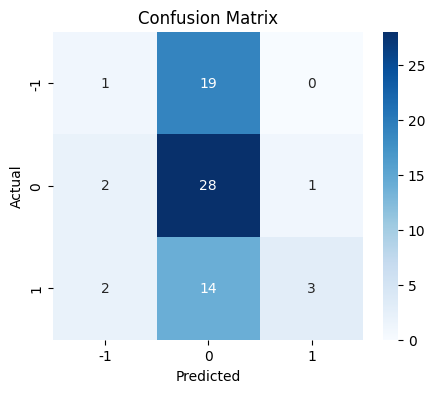

In [49]:
plot_confusion_matrix(y_test, y_pred_test)

In [50]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision      F1
 0.457143 0.457143   0.463993 0.36323


###**Sentence Transformer-Random Forest Model**

In [51]:
# Storing independent variable
X = embedding_matrix


In [52]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
# Building the model
rf_transformer = RandomForestClassifier(random_state=42)


# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [54]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train)


# Predicting on test data
y_pred_test = rf_transformer.predict(X_test)

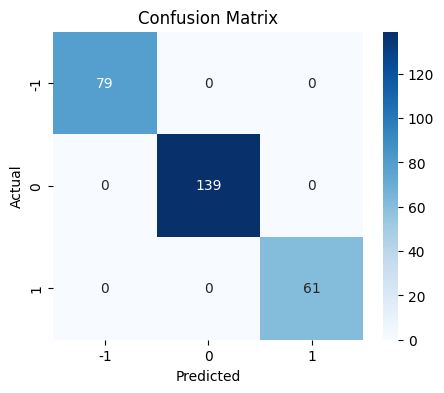

In [55]:
plot_confusion_matrix(y_train, y_pred_train)

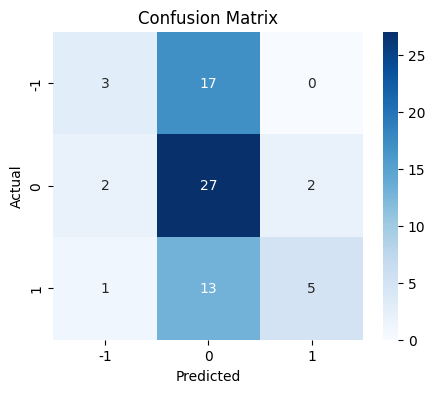

In [56]:
plot_confusion_matrix(y_test, y_pred_test)

In [57]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


### **Building Neural Network Models using different text embeddings**

 **Word2Vec-Neural Network Model**


In [58]:
# Storing independent variable
X = X_word2vec

In [59]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [60]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 output neurons for 3 classes
])
 # 3 output neurons for 3 classes

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4265 - loss: 1.0886 - val_accuracy: 0.4429 - val_loss: 1.0836
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4946 - loss: 1.0631 - val_accuracy: 0.4429 - val_loss: 1.0770
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4982 - loss: 1.0579 - val_accuracy: 0.4429 - val_loss: 1.0769
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0450 - val_accuracy: 0.4429 - val_loss: 1.0820
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0424 - val_accuracy: 0.4429 - val_loss: 1.0871
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0432 - val_accuracy: 0.4429 - val_loss: 1.0852
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0484 - val_accuracy: 0.4429 - val_loss: 1.0838
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0380 - val_accuracy: 0.4429 - val_loss: 1.0838


In [63]:
# Predict class probabilities on training data
y_train_probs = model.predict(X_train)


# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [64]:
# Predict class probabilities on test data
y_test_probs = model.predict(X_test)


# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


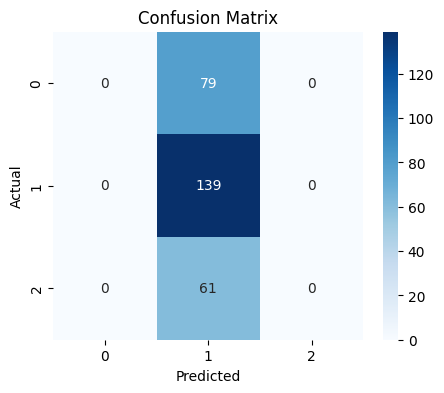

In [65]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

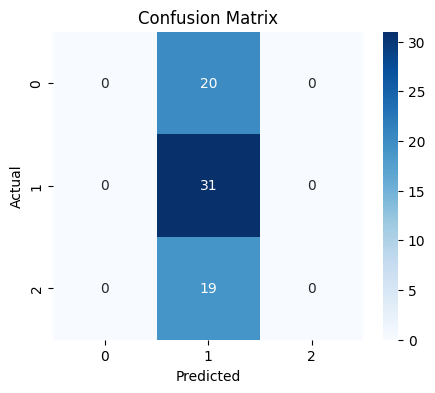

In [66]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [67]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [68]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [70]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))


 # 3 output neurons for 3 classes


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4946 - loss: 1.0774 - val_accuracy: 0.4429 - val_loss: 1.0777
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0489 - val_accuracy: 0.4429 - val_loss: 1.0765
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4982 - loss: 1.0450 - val_accuracy: 0.4429 - val_loss: 1.0831
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4982 - loss: 1.0467 - val_accuracy: 0.4429 - val_loss: 1.0866
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.4982 - loss: 1.0556 - val_accuracy: 0.4429 - val_loss: 1.0839
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.4982 - loss: 1.0387 - val_accuracy: 0.4429 - val_loss: 1.0834
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.4982 - loss: 1.0406 - val_accuracy: 0.4429 - val_loss: 1.0818
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4982 - loss: 1.0412 - val_accuracy: 0.4429 - val_loss: 1.0821


In [72]:
# Predict class probabilities on training data
y_train_probs = model.predict(X_train)


# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [73]:
# Predict class probabilities on test data
y_test_probs = model.predict(X_test)


# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


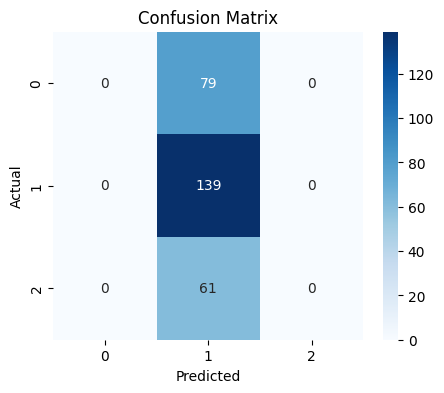

In [74]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

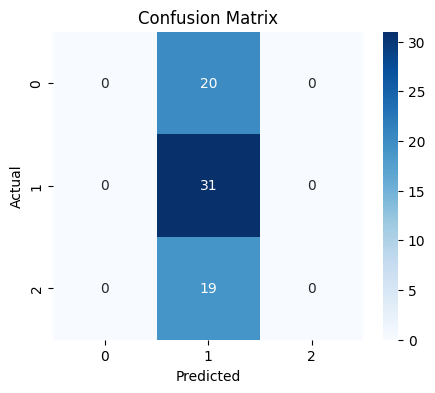

In [75]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [78]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


#MiniLM Random Forest

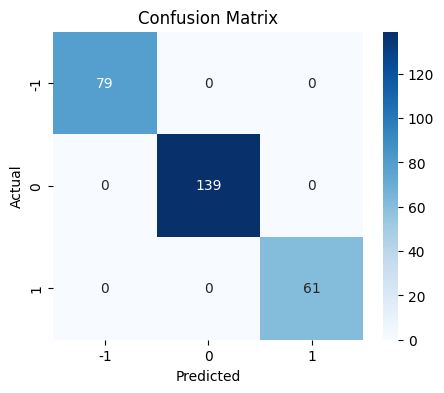

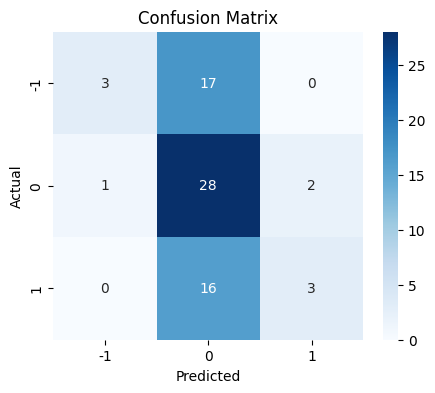

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.580422 0.408851


In [79]:
X = embedding_matrix_minilm
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_minilm = RandomForestClassifier(random_state=42)
rf_minilm.fit(X_train, y_train)

y_pred_train = rf_minilm.predict(X_train)
y_pred_test = rf_minilm.predict(X_test)

plot_confusion_matrix(y_train, y_pred_train)
plot_confusion_matrix(y_test, y_pred_test)

train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train, y_pred_train)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test, y_pred_test)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))

#MiniLM Neural Network

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.4910 - loss: 1.0699 - val_accuracy: 0.4429 - val_loss: 1.0717
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4982 - loss: 1.0372 - val_accuracy: 0.4429 - val_loss: 1.0682
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4982 - loss: 0.9991 - val_accuracy: 0.4429 - val_loss: 1.0701
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4982 - loss: 0.9828 - val_accuracy: 0.4429 - val_loss: 1.0588
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5090 - loss: 0.9515 - val_accuracy: 0.4429 - val_loss: 1.0446
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5269 - loss: 0.9096 - val_accuracy: 0.4571 - val_loss: 1.0373
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5556 - loss: 0.8824 - val_accuracy: 0.5286 - val_loss: 1.0249
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5627 - loss: 0.8606 - val_accuracy: 0.5000 - val_loss: 1.0106

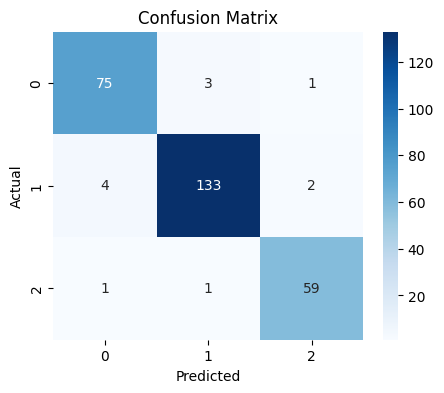

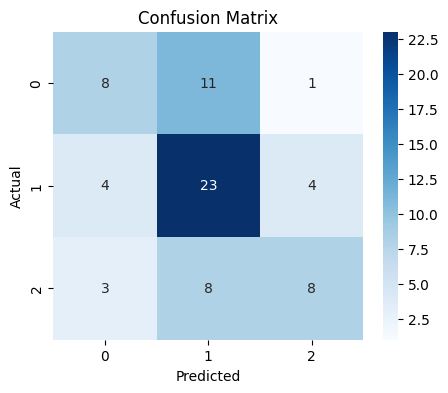

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.956989 0.956989   0.957177 0.957034
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.557143 0.557143   0.561931 0.545387


In [82]:
X = embedding_matrix_minilm
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

import gc
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20, batch_size=32
)

y_train_probs = model.predict(X_train)
y_train_preds = np.argmax(y_train_probs, axis=1)
y_test_probs = model.predict(X_test)
y_test_preds = np.argmax(y_test_probs, axis=1)

plot_confusion_matrix(y_train_mapped, y_train_preds)
plot_confusion_matrix(y_test_mapped, y_test_preds)

train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN.to_string(index=False))
test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN.to_string(index=False))

### **Model Performance Summary and Final Model Selection**


In [83]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.498208,1.0,0.956989
Recall,1.0,0.498208,1.0,0.498208,1.0,0.956989
Precision,1.0,0.248211,1.0,0.248211,1.0,0.957177
F1,1.0,0.331344,1.0,0.331344,1.0,0.957034


In [84]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.457143,0.442857,0.500000,0.442857,0.485714,0.557143
Recall,0.457143,0.442857,0.500000,0.442857,0.485714,0.557143
Precision,0.463993,0.196122,0.546509,0.196122,0.580422,0.561931
F1,0.363230,0.271853,0.442083,0.271853,0.408851,0.545387


## **Conclusions and Recommendations**

#### **Conclusions**

**Word2Vec** - The Word2Vec embeddings, when combined with Random Forest, led to severe overfitting — perfect training accuracy but poor test performance (~46%). With Neural Networks, Word2Vec embeddings performed even worse, staying around **44-50%** accuracy on both train and test, suggesting these embeddings didn't capture enough meaningful signal from the news text for the neural network to learn from.

**Sentence Transformer embeddings** - Sentence Transformer embeddings (both BAAI and MiniLM) generally captured the semantic meaning of the news articles better than Word2Vec. This was most evident with MiniLM combined with a Neural Network, which achieved the best test performance of all six models **(55.7% accuracy, 54.5% F1-score)**, showing these embeddings help the model generalize better to unseen data.

**Neural Networks** - Neural Network performance varied a lot depending on the embeddings used. With Word2Vec and BAAI embeddings, the neural network underperformed, barely crossing **50%** accuracy even on training data. With MiniLM embeddings, however, the neural network performed significantly better, reaching **95.7%** training accuracy and **55.7%** test accuracy — the smallest train-test gap among all models, indicating better generalization.

**Random Forest** - Random Forest consistently achieved **100%** accuracy on training data across all three embedding types, but test accuracy dropped to **45-50%** in every case. This large, consistent gap points to clear overfitting — the model is too complex for the amount of data available and ends up memorizing training examples rather than learning generalizable patterns.



#### **Recommendations**

The overall test accuracy across all models is on the lower side (max ~56%), which is likely due to the limited size of the dataset. Collecting more labeled news data would likely improve model performance significantly.
To reduce overfitting in the Random Forest models, hyperparameter tuning (e.g., limiting max_depth, adjusting min_samples_leaf, or using GridSearchCV to find optimal parameters) should be explored.
Even though MiniLM-NN performed best, there's still considerable room for improvement before this could be trusted for real investment decisions. Techniques like early stopping, adjusting dropout rates, and handling class imbalance (if the sentiment classes aren't evenly distributed) could help close the train-test gap further.
Based on these results, the MiniLM + Neural Network combination is recommended as the final model — it's lighter than BAAI (384 dimensions vs 768), faster to run, and shows the best generalization to unseen data among all six models tested.